<a href="https://colab.research.google.com/github/Bhuvana908/ML-Projects/blob/main/cifar10/CIFAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# CIFAR-10 needs different normalization (3 channels RGB)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),   # data augmentation
    transforms.RandomCrop(32, padding=4), # data augmentation
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),   # CIFAR-10 mean for RGB
        std=(0.2023, 0.1994, 0.2010)     # CIFAR-10 std for RGB
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])


train_data = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_train)
test_data  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False, num_workers=2)


classes = ['Airplane', 'Car', 'Bird', 'Cat', 'Deer',
           'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print(f"Training samples: {len(train_data)}")
print(f"Test samples:     {len(test_data)}")

100%|██████████| 170M/170M [00:05<00:00, 29.5MB/s]


Training samples: 50000
Test samples:     10000


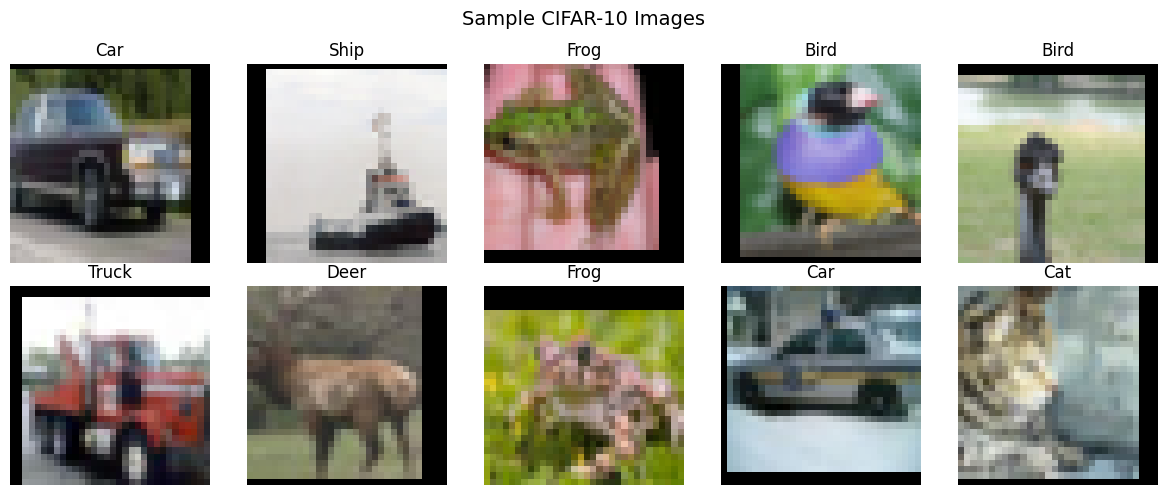

In [ ]:
def show_images(loader, classes):
    images, labels = next(iter(loader))

    # Unnormalize for display
    mean = torch.tensor([0.4914, 0.4822, 0.4465])
    std  = torch.tensor([0.2023, 0.1994, 0.2010])

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i, ax in enumerate(axes.flat):
        img = images[i] * std[:, None, None] + mean[:, None, None]
        img = img.permute(1, 2, 0).numpy()  # CHW → HWC for matplotlib
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(classes[labels[i].item()])
        ax.axis('off')

    plt.suptitle("Sample CIFAR-10 Images", fontsize=14)
    plt.tight_layout()
    plt.show()

show_images(train_loader, classes)

In [ ]:
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolutional layers (extract image features)
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 input channels (RGB)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 32x32 → 16x16
            nn.Dropout(0.25)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 16x16 → 8x8
            nn.Dropout(0.25)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 8x8 → 4x4
            nn.Dropout(0.25)
        )

        # Fully connected layers (classify)
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)    # 10 output classes
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = x.view(x.size(0), -1)   # flatten
        x = self.classifier(x)
        return x

model = CIFAR10_CNN().to(device)
print(model)


total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal Parameters: {total_params:,}")

CIFAR10_CNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)


epochs = 20
train_losses = []
test_accuracies = []

for epoch in range(epochs):
    #Training
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Testing
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)
    scheduler.step()

    print(f"Epoch [{epoch+1:2d}/{epochs}]  Loss: {avg_loss:.4f}  Accuracy: {accuracy:.2f}%")

print("\nTraining Complete!")

Epoch [ 1/20]  Loss: 1.6061  Accuracy: 51.81%
Epoch [ 2/20]  Loss: 1.2738  Accuracy: 63.40%
Epoch [ 3/20]  Loss: 1.1268  Accuracy: 63.14%
Epoch [ 4/20]  Loss: 1.0357  Accuracy: 67.04%
Epoch [ 5/20]  Loss: 0.9733  Accuracy: 70.88%
Epoch [ 6/20]  Loss: 0.9174  Accuracy: 73.78%
Epoch [ 7/20]  Loss: 0.8904  Accuracy: 74.02%
Epoch [ 8/20]  Loss: 0.8487  Accuracy: 76.39%
Epoch [ 9/20]  Loss: 0.8197  Accuracy: 77.83%
Epoch [10/20]  Loss: 0.7918  Accuracy: 77.82%
Epoch [11/20]  Loss: 0.7305  Accuracy: 79.97%
Epoch [12/20]  Loss: 0.7157  Accuracy: 80.49%
Epoch [13/20]  Loss: 0.6948  Accuracy: 80.97%
Epoch [14/20]  Loss: 0.6847  Accuracy: 81.03%
Epoch [15/20]  Loss: 0.6731  Accuracy: 80.87%
Epoch [16/20]  Loss: 0.6591  Accuracy: 82.05%
Epoch [17/20]  Loss: 0.6487  Accuracy: 82.07%
Epoch [18/20]  Loss: 0.6396  Accuracy: 81.80%
Epoch [19/20]  Loss: 0.6291  Accuracy: 83.33%
Epoch [20/20]  Loss: 0.6181  Accuracy: 82.87%

Training Complete!


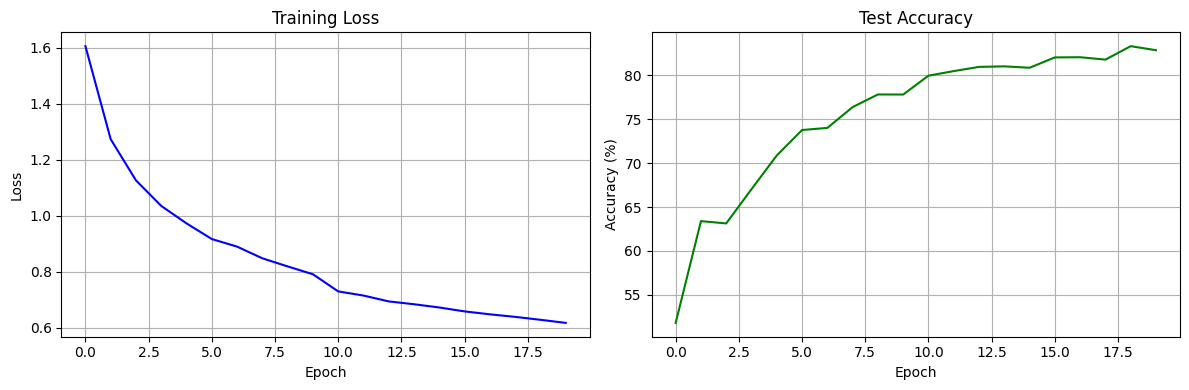

Best Accuracy: 83.33%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, color='blue')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(test_accuracies, color='green')
ax2.set_title('Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Best Accuracy: {max(test_accuracies):.2f}%")

In [ ]:
model.eval()
class_correct = [0] * 10
class_total   = [0] * 10

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += (predicted[i] == labels[i]).item()
            class_total[label]   += 1

print("Accuracy per class:")
print("-" * 30)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{classes[i]:10s}: {acc:.2f}%")

Accuracy per class:
------------------------------
Airplane  : 81.80%
Car       : 91.10%
Bird      : 67.40%
Cat       : 66.40%
Deer      : 75.20%
Dog       : 78.40%
Frog      : 93.70%
Horse     : 86.30%
Ship      : 94.90%
Truck     : 93.50%


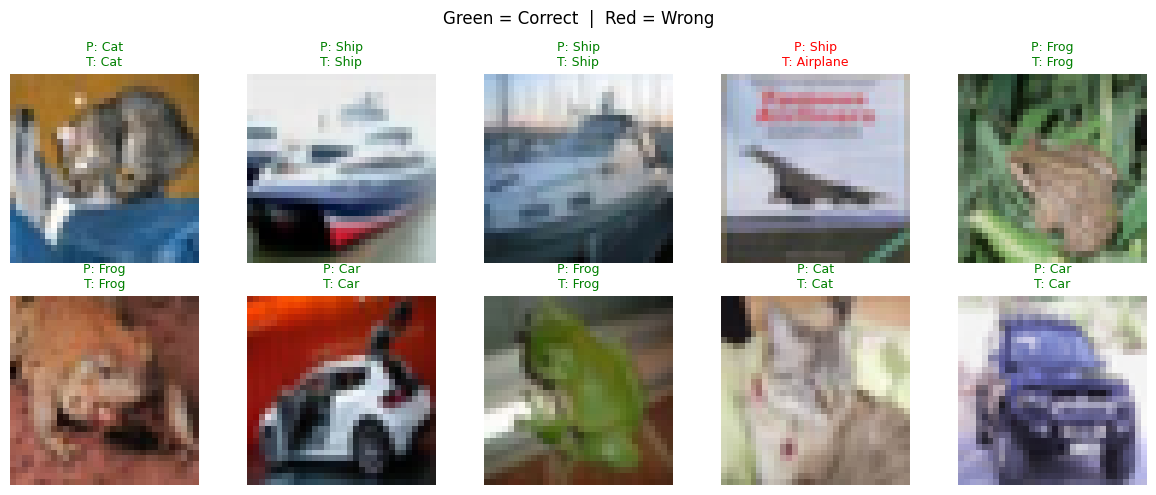

In [ ]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

mean = torch.tensor([0.4914, 0.4822, 0.4465])
std  = torch.tensor([0.2023, 0.1994, 0.2010])

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = images[i].cpu() * std[:, None, None] + mean[:, None, None]
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    pred  = classes[predicted[i].item()]
    true  = classes[labels[i].item()]
    color = 'green' if predicted[i] == labels[i] else 'red'
    ax.set_title(f"P: {pred}\nT: {true}", color=color, fontsize=9)
    ax.axis('off')

plt.suptitle("Green = Correct  |  Red = Wrong", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
torch.save(model.state_dict(), 'cifar10_model.pth')
print("Model saved successfully!")


from google.colab import files
files.download('cifar10_model.pth')


Model saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>